<a href="https://colab.research.google.com/github/lalin15rv-bit/Inteligencia-Artificial/blob/main/CNN/clasificacion_de_digito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_digits        #importamos la librería que requerimos

digits = load_digits()            #Cargamos un conjunto de Datos

In [ ]:
digits.keys()       #Muestra las llaves dentro de la librería

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
print(digits.DESCR)   #Imprime la descripción de la librería

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [ ]:
index = 50          #Depende de la cantidad saldrá otro número diferente

In [ ]:
image = digits.images[index]          #Selecciona una imagen
label = digits.target[index]          #Selecciona una etiqueta

In [ ]:
print(image)        #Imprime la imagen en forma de matriz

[[ 0.  0.  0.  5. 14. 12.  2.  0.]
 [ 0.  0.  7. 15.  8. 14.  4.  0.]
 [ 0.  0.  6.  2.  3. 13.  1.  0.]
 [ 0.  0.  0.  1. 13.  4.  0.  0.]
 [ 0.  0.  1. 11.  9.  0.  0.  0.]
 [ 0.  8. 16. 13.  0.  0.  0.  0.]
 [ 0.  5. 14. 16. 11.  2.  0.  0.]
 [ 0.  0.  0.  6. 12. 13.  3.  0.]]


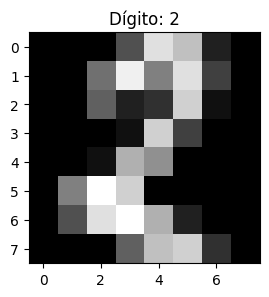

In [ ]:
import matplotlib.pyplot as plt         #Importamos la libreia

plt.figure(figsize=(3, 3))            #Tamaño de la figura
plt.imshow(image, cmap=plt.cm.gray)     #Colocamos el color que queremos en nuestra imagen
plt.title(f'Dígito: {label}')       #Título de nuestra imagen
plt.show()            #Imprime de una forma visual

In [ ]:
import tensorflow as tf       #Importamos una librería
from sklearn.model_selection import train_test_split        #Divide conjuntos en subconjuntos
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target,         #Es unconjuntos de entrenamiento y prueba
    test_size=0.2, random_state=42
)

# One-hot encode the target variable
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [ ]:
print(X_train.shape)
print(X_test.shape)           #imprime las dimenciones de los datos

(1437, 64)
(360, 64)


In [ ]:
reshaped_tensor = tf.reshape(X_train[0], shape=(8, 8))          #Matriz 8x8 y tamben representa
print(reshaped_tensor)

tf.Tensor(
[[ 0.  0.  3. 14.  1.  0.  0.  0.]
 [ 0.  0. 12. 12.  0.  0.  0.  0.]
 [ 0.  3. 16.  6.  0.  0.  0.  0.]
 [ 0.  5. 16.  2.  0.  0.  0.  0.]
 [ 0.  6. 16.  2.  5.  2.  0.  0.]
 [ 0.  4. 16.  2. 12. 15.  2.  0.]
 [ 0.  1. 14. 13.  2. 13. 11.  0.]
 [ 0.  0.  3. 11. 16. 13.  4.  0.]], shape=(8, 8), dtype=float64)


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler          #importamos la biblioteca

# Normalizar los datos
scaler = StandardScaler()       #Aprende las estadísticas
X_train = scaler.fit_transform(X_train)         #aprenden por los datos de entrenamiento
X_test = scaler.transform(X_test)

In [ ]:
reshaped_tensor = tf.reshape(X_train[0], shape=(8, 8))      #entren los datos y los convertimos en una matriz 8x8
# Redondeamos para tener una mejor visualizacion
reshaped_tensor =  tf.floor(reshaped_tensor * 100) / 100          #divide en 100 para tenerlo en su escala ideal
print(reshaped_tensor)          #imprime lo pedido

tf.Tensor(
[[ 0.   -0.35 -0.47  0.5  -2.55 -1.04 -0.41 -0.14]
 [-0.07 -0.62  0.3   0.   -2.19 -1.36 -0.53 -0.14]
 [-0.05  0.12  1.08 -0.2  -1.17 -1.28 -0.56 -0.12]
 [-0.04  0.86  1.13 -1.17 -1.61 -1.29 -0.63 -0.05]
 [ 0.    1.09  1.34 -1.13 -0.91 -1.14 -0.82  0.  ]
 [-0.07  0.82  1.39 -0.83  0.69  1.17 -0.34 -0.1 ]
 [-0.04  0.15  1.14  0.64 -1.43  0.68  1.47 -0.22]
 [-0.03 -0.31 -0.5  -0.25  0.84  1.05  0.45 -0.2 ]], shape=(8, 8), dtype=float64)


In [ ]:
# Redimensionar el tensor a la forma (total, 8, 8)
X_train = tf.reshape(X_train, (X_train.shape[0], 8, 8))
X_test = tf.reshape(X_test, (X_test.shape[0], 8, 8))

In [ ]:
from tensorflow.keras.models import Sequential                          #importamos librerias
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# Crear el modelo de CNN
model = Sequential([
    Conv2D(32, kernel_size=(3, 3),      #números de filtros y el 3,3 define la dimension del filtro junto una matriz
        activation='relu',          #Ayuda al modelo a aprender patrones no lineales
        input_shape=(8, 8, 1)               #8,8 nos indicalas dimensiones de la imágen
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),      #128 neuronas
    Dense(10, activation='softmax')         #10 neuronas
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

# Tasa de aprendizaje deseada
learning_rate = 0.001       #define la tasa de aprendizajes
adam_optimizer = Adam(learning_rate=learning_rate)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(        #Comienza a entrenar
    X_train, y_train,
    epochs=10,        #Número de epocas
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4902 - loss: 1.8991 - val_accuracy: 0.8715 - val_loss: 0.8315
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9271 - loss: 0.6299 - val_accuracy: 0.9375 - val_loss: 0.3656
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9543 - loss: 0.2515 - val_accuracy: 0.9375 - val_loss: 0.2551
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9735 - loss: 0.1422 - val_accuracy: 0.9583 - val_loss: 0.1872
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9797 - loss: 0.1051 - val_accuracy: 0.9479 - val_loss: 0.1554
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9882 - loss: 0.0737 - val_accuracy: 0.9583 - val_loss: 0.1294
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9948 - loss: 0.0502 - val_accuracy: 0.9583 - val_loss: 0.1254
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9915 - loss: 0.0592 - val_accuracy: 0.9653 - val_loss

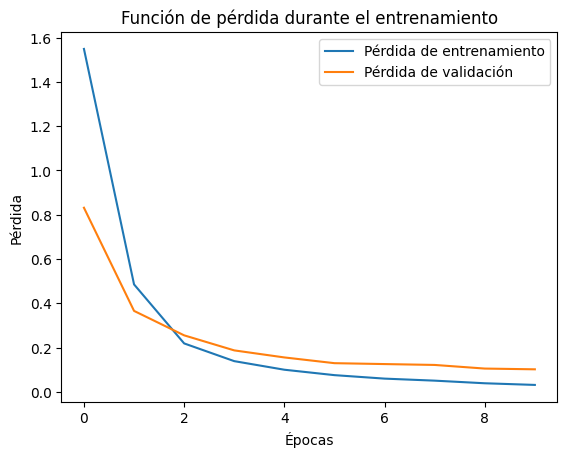

In [ ]:
import matplotlib.pyplot as plt                     #Importamos la biblioteca para graficar

plt.plot(history.history['loss'], label='Pérdida de entrenamiento')             #Informacion de las lineas
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')            #Nombre del eje X
plt.ylabel('Pérdida')          #Nombre del eje y
plt.legend()
plt.title('Función de pérdida durante el entrenamiento')                        #titulo de la tabla
plt.show()        #Nos muestra la tabla

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)                   #copila el modelo
print(f'Loss: {loss}, Accuracy: {accuracy}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0898  
Loss: 0.06890881806612015, Accuracy: 0.980555534362793


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, recall_score

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
# Convert y_test back to multiclass format
y_test_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)
sensitivity = recall_score(y_test_classes, y_pred_classes, average=None)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


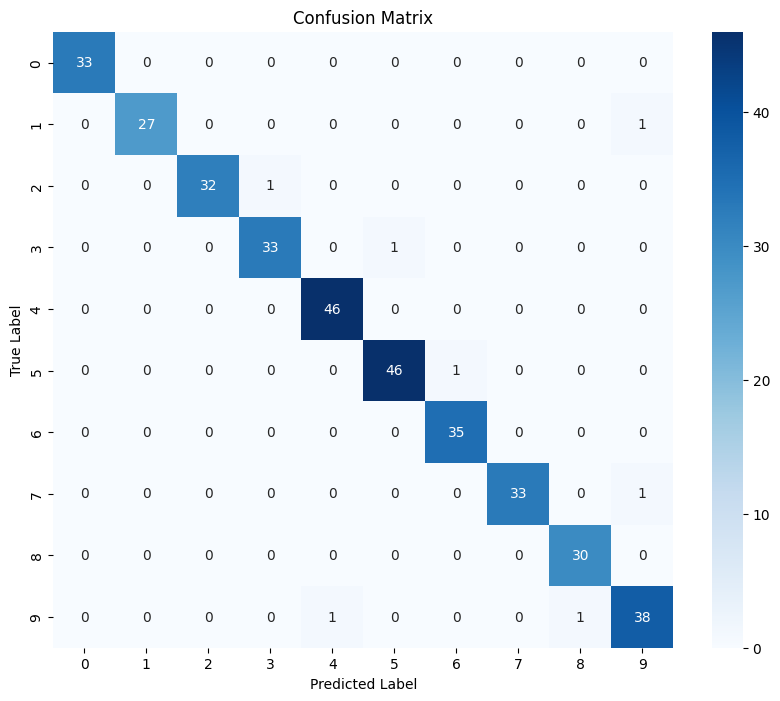

Sensitivity (Recall) for each class:
Class 0: 1.0
Class 1: 0.9642857142857143
Class 2: 0.9696969696969697
Class 3: 0.9705882352941176
Class 4: 1.0
Class 5: 0.9787234042553191
Class 6: 1.0
Class 7: 0.9705882352941176
Class 8: 1.0
Class 9: 0.95


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la matriz de confusión como una imagen de colores
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Mostrar la sensibilidad (recall) para cada clase
print('Sensitivity (Recall) for each class:')
for i in range(10):
    print(f'Class {i}: {sensitivity[i]}')

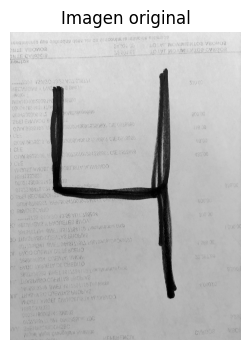

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Cambia por el nombre de tu archivo
ruta = "/content/mi_numero.png"
# Escala de grises ("L")
img = Image.open(ruta).convert("L")

# mostrar la imagen
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

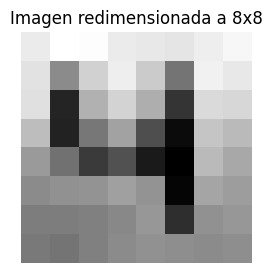

In [ ]:
import matplotlib.pyplot as plt

# redimensionar a 8x8
img_resized = img.resize((8, 8), Image.Resampling.LANCZOS)

# mostrar imagen
plt.figure(figsize=(3, 3))
plt.imshow(img_resized, cmap="gray")
plt.title("Imagen redimensionada a 8x8")
plt.axis("off")
plt.show()

# opcional, guardamos la imagen si es necesario
img_resized.save("imagen_8x8.png")

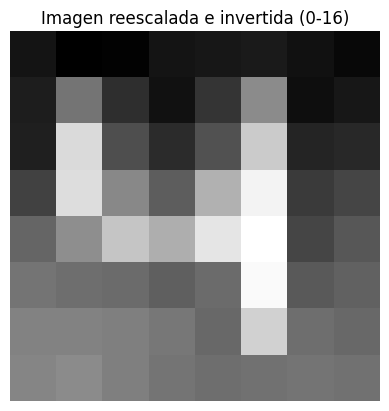

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# reescalar de 0-255 a 0-16 e invertir (fondo negro = 0)
img_array = np.array(img_resized).astype("float32")
img_array = 16 - (img_array / 255 * 16)

# mostrar imagen
plt.imshow(img_array, cmap="gray")
plt.title("Imagen reescalada e invertida (0-16)")
plt.axis("off")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# normalizar
scaler = StandardScaler()
img_flat = img_array
img_scaled = scaler.fit_transform(img_flat)

# Dar forma (1,8,8) que es el input del modelo
img_tensor = img_scaled.reshape(1, 8, 8)

In [ ]:
pred = model.predict(img_tensor)
digit = np.argmax(pred)
print("Predicción:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicción: 6
